In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

##### Carga de datos

In [36]:
df = pd.read_csv('../../../data/CC GENERAL.csv')
df.head(5)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


##### Exploracion y preprocesamiento de datos

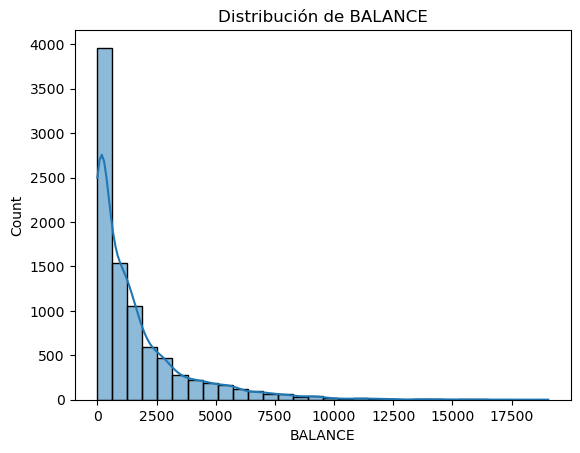

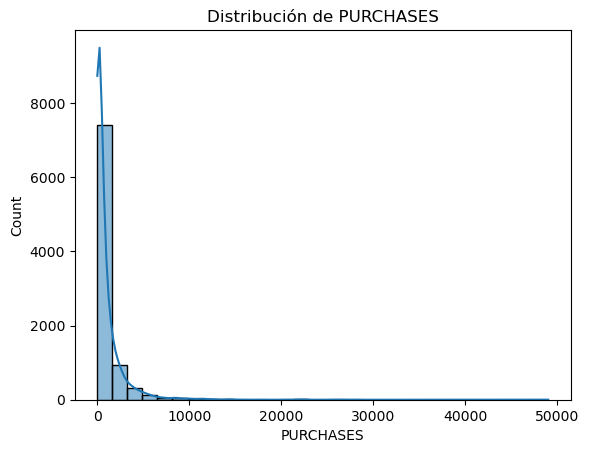

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [37]:
df.drop(columns=["CUST_ID"], inplace=True)

sns.histplot(df["BALANCE"], bins=30, kde=True)
plt.title("Distribución de BALANCE")
plt.show()

sns.histplot(df["PURCHASES"], bins=30, kde=True)
plt.title("Distribución de PURCHASES")
plt.show()


# Manejo de valores nulos
print(df.isnull().sum())
df.fillna(df.mean(), inplace=True)

# Eliminación de valores atípicos (outliers) usando el rango intercuartílico
numerical_features = df.select_dtypes(include=["float64", "int64"]).columns
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]


# Estandarización de las variables
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[numerical_features])

##### Aplicacion del Kmeans

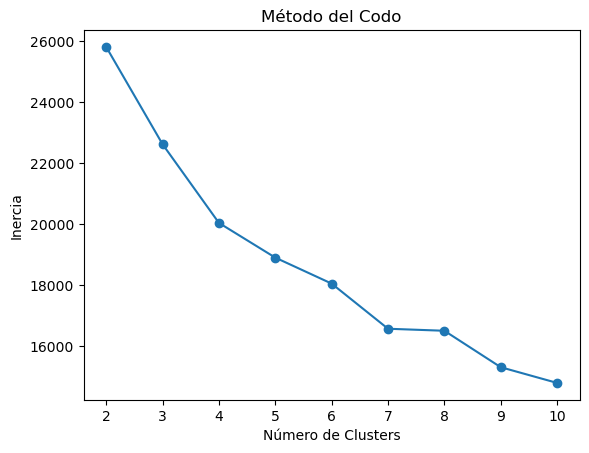

In [38]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.show()

* De acuerdo al metodo del codo, el numero de clusters optimos es de 3 o 4

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# Evaluación de K-means
kmeans_silhouette = silhouette_score(data_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(data_scaled, kmeans_labels)
print(f"Silhouette Score (K-means): {kmeans_silhouette}")
print(f"Calinski-Harabasz Index (K-means): {kmeans_calinski}")

Silhouette Score (K-means): 0.178064323694909
Calinski-Harabasz Index (K-means): 499.0814972546365


##### Aplicacion DBSCAN

Silhouette Score (DBSCAN): -0.1873765161583701
Calinski-Harabasz Index (DBSCAN): 39.1842906504131


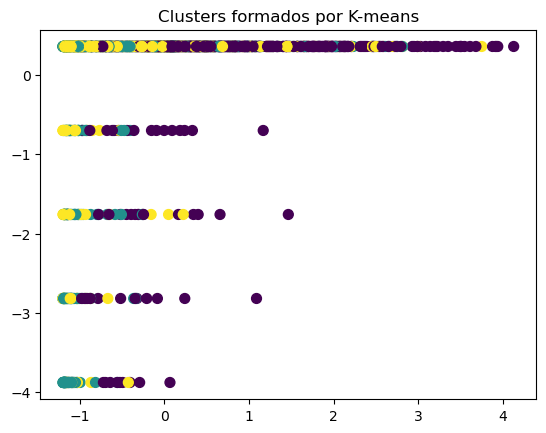

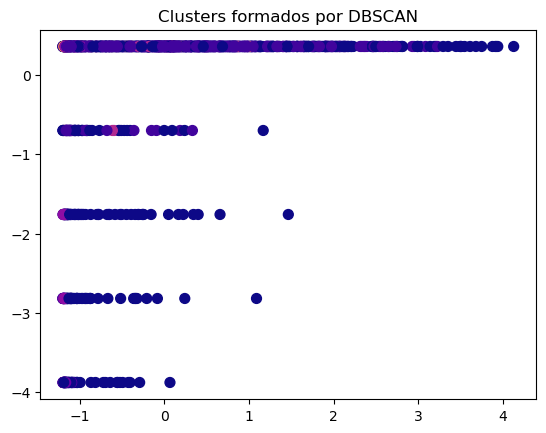

In [40]:
# Probar diferentes valores de epsilon y min_samples
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Evaluación de DBSCAN
dbscan_silhouette = silhouette_score(data_scaled, dbscan_labels, metric='euclidean') if len(set(dbscan_labels)) > 1 else "No se puede calcular"
dbscan_calinski = calinski_harabasz_score(data_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else "No se puede calcular"
print(f"Silhouette Score (DBSCAN): {dbscan_silhouette}")
print(f"Calinski-Harabasz Index (DBSCAN): {dbscan_calinski}")

# 4. Comparación visual de los resultados
# Visualización de K-means
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title("Clusters formados por K-means")
plt.show()

# Visualización de DBSCAN
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=dbscan_labels, cmap='plasma', s=50)
plt.title("Clusters formados por DBSCAN")
plt.show()


In [41]:
# 5. Interpretación de resultados
print("\nInterpretación de resultados:")
print("Los clusters formados por K-means son más cohesivos debido a los altos puntajes de Silhouette y Calinski-Harabasz.")
print("DBSCAN detectó outliers, pero sus métricas son inferiores para este dataset.")


Interpretación de resultados:
Los clusters formados por K-means son más cohesivos debido a los altos puntajes de Silhouette y Calinski-Harabasz.
DBSCAN detectó outliers, pero sus métricas son inferiores para este dataset.
